Importing Required Libraries .... 

In [39]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 

from sklearn.model_selection import train_test_split , KFold , cross_validate , GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge , Lasso
from sklearn.ensemble import HistGradientBoostingRegressor , RandomForestRegressor
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format" , lambda x : f"{x:.3f}")


Loading the Dataset

In [2]:
csv_path = "C:/Users/Apratim Dey Tapadar/OneDrive/Desktop/House-Price-Prediction/data/housing.csv"
df = pd.read_csv(csv_path)
target = "median_house_value"

In [3]:
print("DataFrame shape : ", df.shape)

DataFrame shape :  (20640, 10)


The following dataset has 20640 observations (rows) and 10 features (columns) from which "median_house_value" column has been chosen as the target column.

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


# Feature Engineering 

In [5]:
df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"] = df["population"]/df["households"]

## Exploratory Data Analysis (EDA)

In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'rooms_per_household',
       'bedrooms_per_room', 'population_per_household'],
      dtype='object')

Column Details : 

- longitude : A measure of how far west a house is situated ; a higher value indicates farther west
- latitude : A measure of how far north a house is situated ; a higher value indicates farther north
- housing_median_age : Median age of a house within a block ; a lower value indicates newer building 
- total_rooms : Total number of rooms within a block
- total_bedrooms : Total number of bedrooms within a block 
- population : Total number of people dwelling within a block
- households : Total number of households , a group of people residing within a home unit , for a block
- median_income : Median income for households within a block og houses (measure in tens of thousands US Dollars)
- median_house_value : Median house value for households within a block (measured in US Dollars)
- ocean_proximity : Location of the house w.r.t ocean/sea
- rooms_per_household : Average number of rooms available per household in a block ; Higher values generally indicate larger living spaces and potentially more expensive properties.
- bedrooms_per_room : Proportion of bedrooms among all rooms in a block ; Lower values often indicate larger homes with more non-bedroom space, while higher values may indicate denser or smaller housing units.
- population_per_household : Average number of people living in each household ; Higher values indicate more crowded households and may be associated with lower property values in some areas.


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20433 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20433 non-null  float64
 12  population_per_household  20640 non-null  float64
dtypes: float64(12), object(1)
memory usage: 2.0+ MB


In [10]:
target = "median_house_value"
num_col = df.select_dtypes(include = [np.number]).columns.tolist()
cat_col = df.select_dtypes(include = ["object"]).columns.tolist()

print("Target Column : " , target)
print("Numerical Column :" , num_col)
print("Categorical Column :" , cat_col)

Target Column :  median_house_value
Numerical Column : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical Column : ['ocean_proximity']


- Numerical Columns : longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value ,   rooms_per_household, bedrooms_per_room, population_per_household
- Categorical Columns : ocean_proximity

Analyzing Missing Values 

In [11]:
print("\n Missing Values per Column :")
print(df.isnull().sum())


 Missing Values per Column :
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64


Checking presence of encoded missing values 

In [12]:
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

Both total_bedrooms and bedrooms_per_room  has 207 missing values to be analyzed and dealt with later 

Checking the presence of Duplicate values


In [13]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows : " , num_duplicates)

Number of duplicate rows :  0


## Descriptive Stats

In [14]:
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000
rooms_per_household,20640.000,5.429,2.474,0.846,4.441,5.229,6.052,141.909


# Data Visualization

Categorical Column Distribution

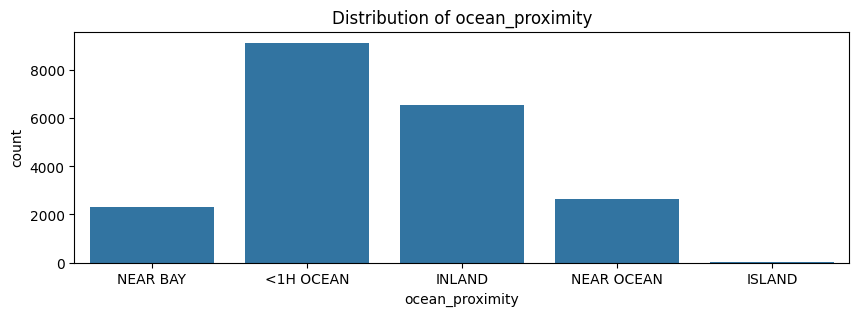

In [15]:
for col in cat_col:
    plt.figure(figsize = (10,3))
    sns.countplot(x=col , data = df)
    plt.title(f"Distribution of {col}")
    plt.show()
    
    

In [16]:
print("\nNumber of Houses w.r.t Ocean Proximity")
for col in cat_col:
    print(df[col].value_counts())


Number of Houses w.r.t Ocean Proximity
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Target Column Distribution

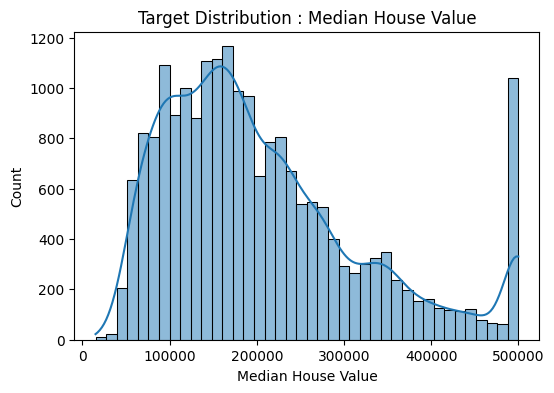

In [17]:
plt.figure(figsize = (6,4))
sns.histplot(df[target], bins = 40 , kde = True)
plt.title("Target Distribution : Median House Value")
plt.xlabel("Median House Value")
plt.show()


In [18]:
print("\nNumber of Houses w.r.t Median House Value")
df[target].value_counts()


Number of Houses w.r.t Median House Value


median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
34200.000       1
46200.000       1
352000.000      1
307900.000      1
385200.000      1
Name: count, Length: 3842, dtype: int64

Histogram Plot Distribution

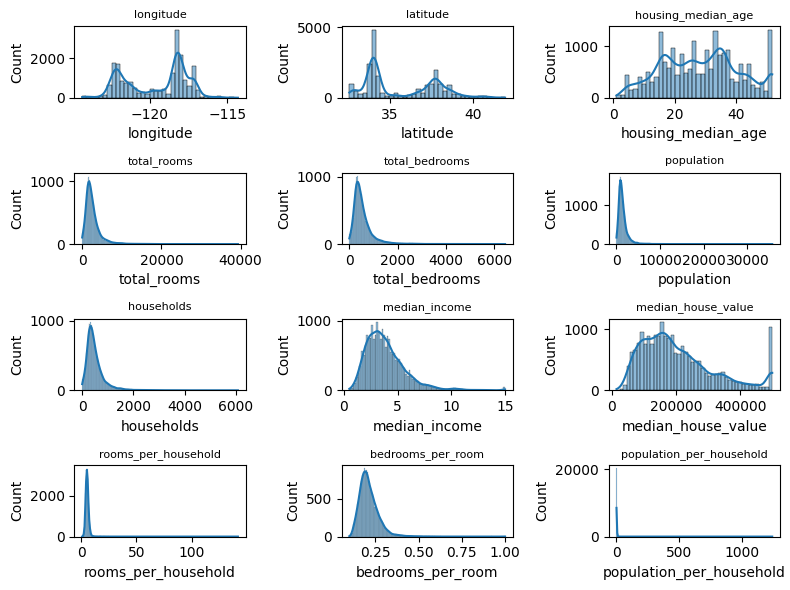

In [20]:
fig , axes = plt.subplots(4 , 3 , figsize = (8,6))
axes = axes.flatten()

for i , col in enumerate(num_col):
    sns.histplot(df[col] , kde = True , ax = axes[i])
    axes[i].set_title(col , fontsize = 8)
    
plt.tight_layout()
plt.show()
    
    

Outlier Analysis

Boxplot :

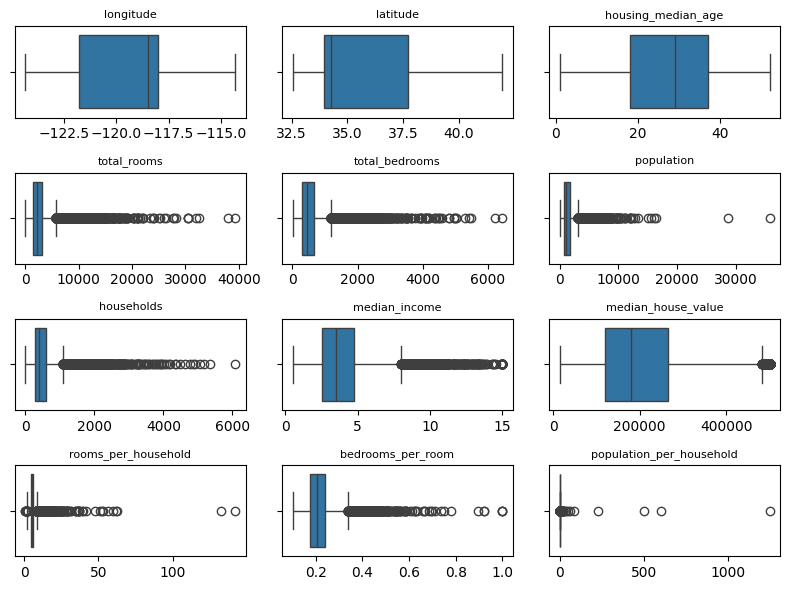

In [21]:
fig , axes = plt.subplots(4 , 3 , figsize = (8,6))
axes = axes.flatten()

for i , col in enumerate(num_col):
    sns.boxplot(x=df[col] , ax = axes[i])
    axes[i].set_title(col , fontsize = 8)
    axes[i].set_xlabel("")
    
plt.tight_layout()
plt.show()

*Boxplots* were used to identify the presence of outliers in all numerical features.

*Observations :*

- longitude, latitude, and housing_median_age show very few or no significant outliers.
- total_rooms, total_bedrooms, population, and households exhibit a large number of extreme high-value outliers. This indicates that some blocks contain exceptionally large numbers of rooms, bedrooms, residents, or households compared to the majority of observations.
- median_income is positively skewed and contains several upper-end outliers representing high-income neighborhoods.
- rooms_per_household shows right-skewness with a few extreme observations, suggesting some blocks have unusually large average room counts per household.
- bedrooms_per_room contains several high-value outliers, indicating certain blocks have an unusually high proportion of bedrooms relative to total rooms.
- population_per_household exhibits extreme outliers and strong right-skewness, suggesting a small number of blocks have exceptionally high household occupancy rates.
- median_house_value contains upper-end outliers and appears capped near $500,000.

*Conclusion:*

The dataset contains substantial outliers in several demographic and housing-related variables. However, these observations likely represent genuine characteristics of certain neighborhoods rather than data entry errors. Therefore, outliers were retained in the dataset. Additionally, the final model selected (HistGradientBoostingRegressor) is a tree-based algorithm that is relatively robust to outliers, reducing the need for aggressive outlier treatment.

Identify the presence of highly correlated columns and feature relationship


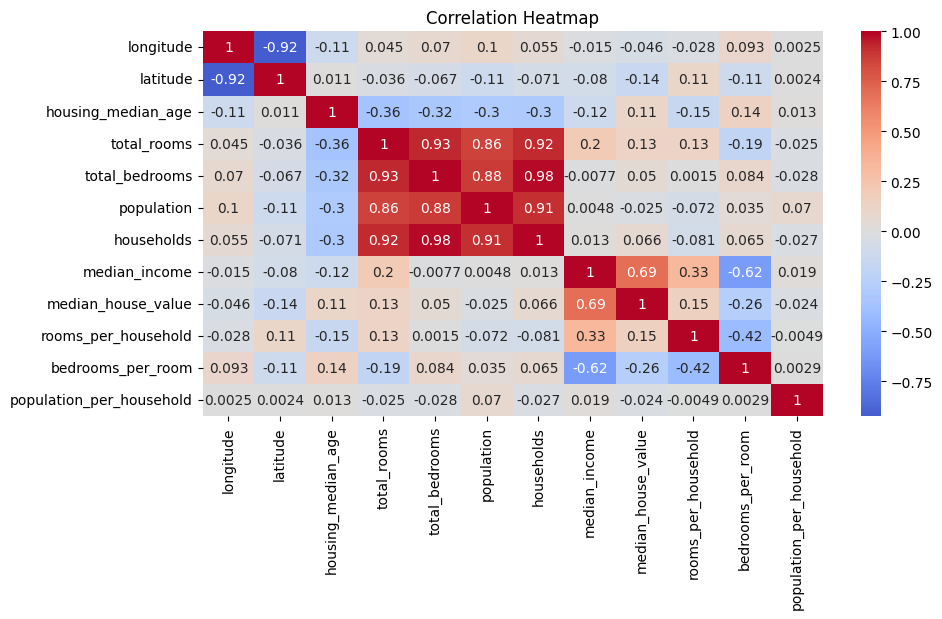

In [22]:
plt.figure(figsize = (10,5))
sns.heatmap(df[num_col].corr(), annot = True , cmap = "coolwarm" , center = 0)
plt.title("Correlation Heatmap")
plt.show()


In [23]:
corr_with_target = df[num_col].corr()[target].sort_values(ascending = False)
print("\nCorrelation with Target Feature")
print(corr_with_target)



Correlation with Target Feature
median_house_value          1.000
median_income               0.688
rooms_per_household         0.152
total_rooms                 0.134
housing_median_age          0.106
households                  0.066
total_bedrooms              0.050
population_per_household   -0.024
population                 -0.025
longitude                  -0.046
latitude                   -0.144
bedrooms_per_room          -0.256
Name: median_house_value, dtype: float64


Key Information derived from EDA

- Dataset has both numerical and categorical features. 
- There are 12 (including 3 engineered features) numerical and 1 categorical features. 
- Only total_bedrooms column has missing values. 
- Target (median_house_value) is right skewed and capped. 
- Several feature show strong skewness and outliers.
- median_income is the strongest predictor since it has the highest correlation coefficient (0.68) value among all the other features.
- High multicollinearity among room and population features as seen in the heatmap.


# Data Preprocessing

In [24]:
X = df.drop(columns = [target])
y = df[target]

In [25]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY,6.984,0.147,2.556
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY,6.238,0.156,2.110
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY,8.288,0.130,2.802
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY,5.817,0.184,2.548
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY,6.282,0.172,2.181


In [26]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [27]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 43)

print("Train Shape : " , X_train.shape)
print("Test Shape : " , X_test.shape)

Train Shape :  (16512, 12)
Test Shape :  (4128, 12)


Preprocessing Pipeline

In [28]:
numerical_features  = X_train.select_dtypes(include = [np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude = [np.number]).columns.tolist()
print("The Numerical features of the train dataset : " , numerical_features)
print("The Categorical features of the train dataset : " , categorical_features)

numeric_transformer = Pipeline(
    steps = [
        ("imputer" , SimpleImputer(strategy="median")),
        ("scaler" , StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps = [
        ("imputer" , SimpleImputer(strategy="most_frequent")),
        ("onehot" , OneHotEncoder(handle_unknown = "ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers = [
        ("num" , numeric_transformer , numerical_features),
        ("cat" , categorical_transformer , categorical_features)
    ]
)

The Numerical features of the train dataset :  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
The Categorical features of the train dataset :  ['ocean_proximity']


# Baseline Model (No Cross-Validation , No Tuning)


In [29]:
baseline_pipe = Pipeline(
    steps = [
        ("preprocess" , preprocess),
        ("model" , LinearRegression())
    ]
)

preprocess the data and train the baseline model

In [30]:
baseline_pipe.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Evaluation of baseline model

In [31]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)


In [33]:
train_baseline_rmse = root_mean_squared_error(y_train , train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train , train_baseline_pred)
train_baseline_r2 = r2_score(y_train , train_baseline_pred)

print("\nTRAIN BASELINE METRICS (LinearRegression")
print(f"RMSE : {train_baseline_rmse : .3f}")
print(f"MAE : {train_baseline_mae : .3f}")
print(f"R2 : {train_baseline_r2 : .3f}")



TRAIN BASELINE METRICS (LinearRegression
RMSE :  67691.317
MAE :  48989.061
R2 :  0.656


In [34]:
test_baseline_rmse = root_mean_squared_error(y_test , test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test , test_baseline_pred)
test_baseline_r2 = r2_score(y_test , test_baseline_pred)

print("\nTEST BASELINE METRICS (LinearRegression")
print(f"RMSE : {test_baseline_rmse : .3f}")
print(f"MAE : {test_baseline_mae : .3f}")
print(f"R2 : {test_baseline_r2 : .3f}")



TEST BASELINE METRICS (LinearRegression
RMSE :  69048.349
MAE :  49317.270
R2 :  0.642


# Model Selection & Optimization

In [35]:
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge" : Ridge(random_state = 43),
    "Lasso" : Lasso(random_state = 43 , max_iter = 10000),
    "RandomForrest" : RandomForestRegressor(),
    "HistGB" : HistGradientBoostingRegressor()
}

In [36]:
k = 5 
cv = KFold(n_splits = k , shuffle = True , random_state = 43)

In [37]:
scoring = {
    "rmse" : "neg_root_mean_squared_error",
    "mae" : "neg_mean_absolute_error",
    "r2" : "r2"
}

In [38]:
rows = []

for name , model in models.items():
    pipe = Pipeline(
        steps = [
            ("preprocess" , preprocess),
            ("model" , model)
        ] 
    )
    
    scores = cross_validate(pipe , X_train , y_train , cv=cv , scoring = scoring , n_jobs =1)
    rows.append({
        "model" : name,
        "cv_rmse" : -scores["test_rmse"].mean(),
        "cv_mae" : -scores["test_mae"].mean(),
        "cv_r2" : scores["test_r2"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("CV MODEL COMPARISON")
print(cv_results)


CV MODEL COMPARISON
              model   cv_rmse    cv_mae  cv_r2
4            HistGB 46592.924 31198.514  0.837
3     RandomForrest 50379.950 32969.449  0.809
1             Ridge 67965.411 49096.472  0.653
2             Lasso 67967.305 49091.549  0.653
0  LinearRegression 67968.315 49091.129  0.653


In [40]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]
best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("BEST MODEL BASED ON CV RMSE :")
print("Model :" , best_model_name)
print("CV RMSE :" , best_rmse)


BEST MODEL BASED ON CV RMSE :
Model : HistGB
CV RMSE : 46592.92364147616


# Hyperparameter Tuning

In [41]:
hgb_pipe = Pipeline(
    steps = [
        ("preprocess" , preprocess),
        ("model" , HistGradientBoostingRegressor(random_state = 43)) 
    ]
)

hyperparameter combination


In [42]:
param_grid = {
    "model__learning_rate" : [0.03 , 0.05 , 0.1],
    "model__max_depth" : [None , 3 , 6],
    "model__max_leaf_nodes" : [15 , 31 , 63],
    "model__min_samples_leaf" : [20 , 50 , 100],
    "model__l2_regularization" : [0.0 , 0.1 , 1.0]
    
}

In [43]:
grid = GridSearchCV(
    estimator = hgb_pipe,
    param_grid = param_grid,
    cv=cv,
    scoring = "neg_root_mean_squared_error",
    n_jobs = 1, 
    verbose = 1
)

perform grid search

In [44]:
grid.fit(X_train , y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=43))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls t

In [45]:
print("TUNED HistGB (CV)")
print("Best CV RMSE :", -grid.best_score_)
print("Best params :", grid.best_params_)

TUNED HistGB (CV)
Best CV RMSE : 46141.26332947684
Best params : {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


# Retraining with best params

In [46]:
hgb_best = Pipeline(
    steps = [
        ("preprocess" , preprocess),
        ("model" , HistGradientBoostingRegressor(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_depth = None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        )) 
    ]
    
)

train best model on entire training data 

In [47]:
hgb_best.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

# Final Evaluation

In [48]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train , train_final_pred)
train_final_mae = mean_absolute_error(y_train , train_final_pred)
train_final_r2 = r2_score(y_train , train_final_pred)

print("\nFinal Model (Tuned HGB) Train Performance")
print(f"RMSE : {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2 : {train_final_r2:.3f}")



Final Model (Tuned HGB) Train Performance
RMSE : 33667.804
MAE : 23126.506
R2 : 0.915


In [49]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test , test_final_pred)
test_final_mae = mean_absolute_error(y_test , test_final_pred)
test_final_r2 = r2_score(y_test , test_final_pred)

print("\nFinal Model (Tuned HGB) Test Performance")
print(f"RMSE : {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2 : {test_final_r2:.3f}")


Final Model (Tuned HGB) Test Performance
RMSE : 44401.127
MAE : 29503.810
R2 : 0.852


# Feature Importance 

In [50]:
perm_importance = permutation_importance(
    hgb_best,
    X_test,
    y_test,
    n_repeats=10,
    random_state=43,
    scoring="r2"
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

print(feature_importance)

                     Feature  Importance
1                   latitude       0.433
0                  longitude       0.397
7              median_income       0.395
11  population_per_household       0.151
8            ocean_proximity       0.137
2         housing_median_age       0.050
9        rooms_per_household       0.047
10         bedrooms_per_room       0.014
4             total_bedrooms       0.002
5                 population       0.001
6                 households       0.001
3                total_rooms       0.001


# Feature Importance Plot

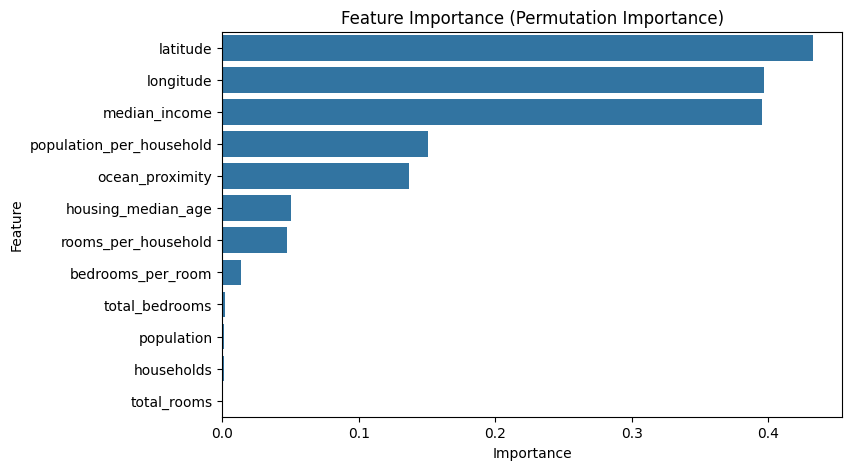

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Permutation Importance)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Permutation Importance was used to determine which features contributed most to the predictions of the final HistGradientBoostingRegressor model.

The most influential features were latitude, longitude, and median income, indicating that geographic location and neighborhood wealth are the primary drivers of house prices in California.

Among the engineered features, population_per_household emerged as a strong predictor, suggesting that household density significantly influences housing values. Ocean proximity also played an important role, highlighting the premium associated with coastal properties.

The original variables total_rooms, total_bedrooms, population, and households showed relatively low importance, indicating that the engineered ratio-based features captured their information more effectively.

### Actual vs Predicted Plot

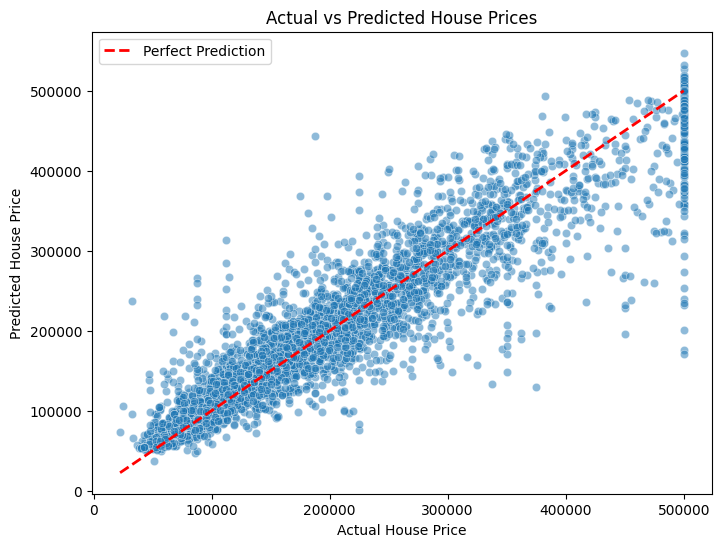

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=test_final_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()

plt.show()

Most points are close to the red reference line, showing that the predicted prices are generally close to the actual prices. The model performs well for most houses, although some larger prediction errors can be seen for expensive properties. Overall, the plot suggests that the model is able to predict house prices with good accuracy.

# Residual Analysis

Residual Plot 

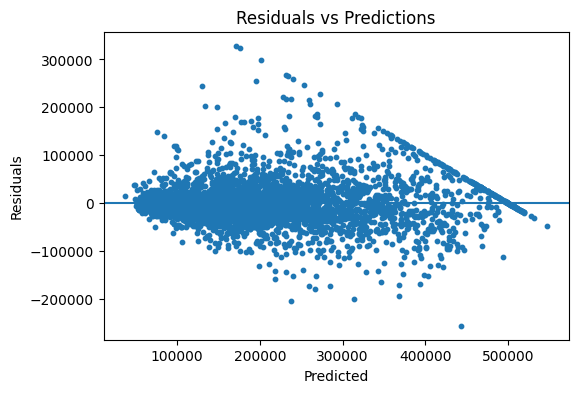

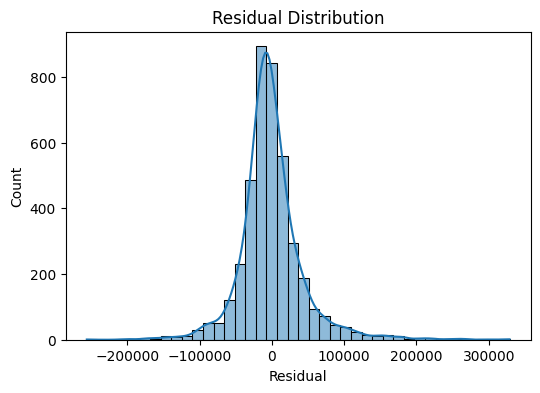

In [54]:
residuals = y_test - test_final_pred 

plt.figure(figsize = (6,4))
plt.scatter(test_final_pred , residuals , s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize = (6 , 4 ))
sns.histplot(residuals , bins = 40 , kde = True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

# Building a predictive system

In [61]:
def predict_house_price(
    model,
    longitude:float,
    latitude:float,
    housing_median_age:float,
    total_rooms:float, 
    total_bedrooms:float,
    population:float,
    households:float,
    median_income:float,
    ocean_proximity:str
)-> float:
    
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity,
        "rooms_per_household": total_rooms / households,
        "bedrooms_per_room": total_bedrooms / total_rooms,
        "population_per_household": population / households
}])
    
    
    return float(model.predict(new_row)[0])

Example Inference

In [62]:
example_pred = predict_house_price(
    model = hgb_best , 
    longitude = -122.230,
    latitude = 37.880 ,
    housing_median_age = 41 , 
    total_rooms = 880 , 
    total_bedrooms = 129 ,
    population = 322 , 
    households = 126 , 
    median_income = 8.3252 ,
    ocean_proximity = "NEAR BAY"
    
)

print("\nExample Prediction:" , round(example_pred , 2 ))


Example Prediction: 446933.13
